In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Step 1: Generate synthetic data for classification
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_classes=2,
    random_state=42
)

In [2]:
# =====================================================
# Regular CV
# =====================================================

# Step 2: CV set-up
c_value = 1
n_fold = 5
cv = StratifiedKFold(n_splits=n_fold, shuffle=True, random_state=42)
accuracies = []

In [3]:
# Step 3: Performing CV
for train_index, test_index in cv.split(X, y):
    # Current split
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Training
    model = LogisticRegression(C=c_value, random_state=42, max_iter=1000, solver='liblinear')
    model.fit(X_train, y_train)

    # Testing
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

mean_accuracy = np.mean(accuracies)
print(f"Average Accuracy (Fixed C = {c_value}): {mean_accuracy:.4f}")

Average Accuracy (Fixed C = 1): 0.8690


In [4]:
# =====================================================
# Nested CV
# =====================================================

# Step 2: Nested CV set-up
c_values = [0.001, 0.01, 0.1, 1, 10, 100]
outer_cv = StratifiedKFold(n_splits=n_fold, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=n_fold, shuffle=True, random_state=42)

In [5]:
# Step 3: Performing nested CV
outer_accuracies = []
best_cs = []

# Outer loop
for train_index, test_index in outer_cv.split(X, y):
    # Outer split
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    inner_accuracies = []

    # Loop over C values
    for c_value in c_values:
        inner_fold_accuracies = []

        # Inner loop
        for inner_train_index, inner_test_index in inner_cv.split(X_train, y_train):
            # Inner split
            inner_X_train = X_train[inner_train_index]
            inner_X_test = X_train[inner_test_index]
            inner_y_train = y_train[inner_train_index]
            inner_y_test = y_train[inner_test_index]

            # Inner training
            inner_model = LogisticRegression(
                C=c_value,
                random_state=42,
                max_iter=1000,
                solver='liblinear'
            )
            inner_model.fit(inner_X_train, inner_y_train)

            # Inner testing
            inner_y_pred = inner_model.predict(inner_X_test)
            inner_fold_accuracy = accuracy_score(inner_y_test, inner_y_pred)
            inner_fold_accuracies.append(inner_fold_accuracy)

        # Inner mean accuracy for this C
        inner_mean_accuracy = np.mean(inner_fold_accuracies)
        inner_accuracies.append(inner_mean_accuracy)

    # Find best C value from inner CV
    best_c_index = np.argmax(inner_accuracies)
    best_c = c_values[best_c_index]
    best_cs.append(best_c)

    # Outer training and testing
    outer_model = LogisticRegression(
        C=best_c,
        random_state=42,
        max_iter=1000,
        solver='liblinear'
    )
    outer_model.fit(X_train, y_train)
    outer_y_pred = outer_model.predict(X_test)
    outer_accuracy = accuracy_score(y_test, outer_y_pred)
    outer_accuracies.append(outer_accuracy)

outer_mean_accuracy = np.mean(outer_accuracies)

print("Best C values per outer fold:", best_cs)
print(f"Average Outer Accuracy: {outer_mean_accuracy:.4f}")
print(f"Accuracy Difference (Nested - Fixed): {outer_mean_accuracy - mean_accuracy:.4f}")

Best C values per outer fold: [0.01, 0.01, 0.1, 1, 1]
Average Outer Accuracy: 0.8680
Accuracy Difference (Nested - Fixed): -0.0010


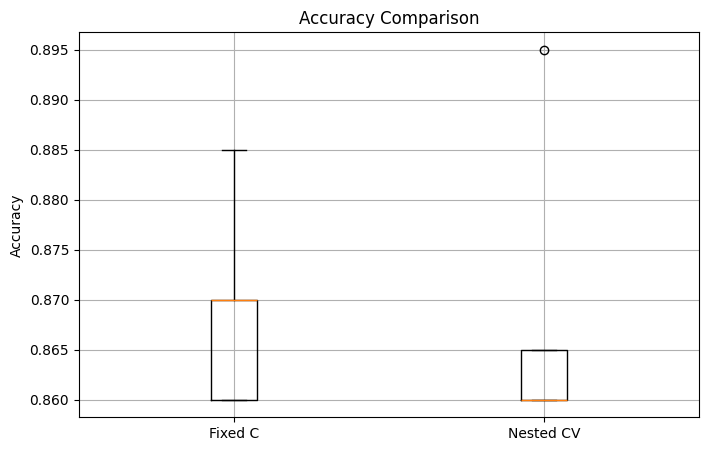

In [6]:
# =====================================================
# Plot
# =====================================================

plt.figure(figsize=(8, 5))
plt.boxplot([accuracies, outer_accuracies], tick_labels=['Fixed C', 'Nested CV'])
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.grid(True)
plt.show()